# Exploration des données

## Importation des données

In [89]:
import pandas as pd
import s3fs

In [90]:
BUCKET = "xifar19"
FILE_KEY_S3 = "boardgames/bgg_dataset.csv"
FILE_PATH_S3 = f"{BUCKET}/{FILE_KEY_S3}"

fs = s3fs.S3FileSystem()

with fs.open(FILE_PATH_S3, mode="rb") as file_in:
    df = pd.read_csv(file_in, sep=";")

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20343 non-null  object 
 2   Year Published      20342 non-null  float64
 3   Min Players         20343 non-null  int64  
 4   Max Players         20343 non-null  int64  
 5   Play Time           20343 non-null  int64  
 6   Min Age             20343 non-null  int64  
 7   Users Rated         20343 non-null  int64  
 8   Rating Average      20343 non-null  object 
 9   BGG Rank            20343 non-null  int64  
 10  Complexity Average  20343 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 2.2+ MB


In [92]:
df.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,"8,61",2,"2,84",65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"


ID est une colonne d'ID propre à BGG, à voir si je garde pour intégrer des images.

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20343 non-null  object 
 2   Year Published      20342 non-null  float64
 3   Min Players         20343 non-null  int64  
 4   Max Players         20343 non-null  int64  
 5   Play Time           20343 non-null  int64  
 6   Min Age             20343 non-null  int64  
 7   Users Rated         20343 non-null  int64  
 8   Rating Average      20343 non-null  object 
 9   BGG Rank            20343 non-null  int64  
 10  Complexity Average  20343 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 2.2+ MB


Je remarque qu'il manque 16 valeurs dans la colonne ID, environ 600 valeurs dans la colonne Mechanics et environs 10 000 valeurs dans la colonne Domains.
Je vais d'office supprimer les enregistrements où les valeurs sont manquantes dans la colonne ID

In [94]:
df_na=df[df['ID'].isna()]

In [95]:
df_na['ID'].size

16

In [96]:
df_clean=df.dropna(subset='ID')

In [97]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20327 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20327 non-null  object 
 2   Year Published      20327 non-null  float64
 3   Min Players         20327 non-null  int64  
 4   Max Players         20327 non-null  int64  
 5   Play Time           20327 non-null  int64  
 6   Min Age             20327 non-null  int64  
 7   Users Rated         20327 non-null  int64  
 8   Rating Average      20327 non-null  object 
 9   BGG Rank            20327 non-null  int64  
 10  Complexity Average  20327 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 2.3+ MB


In [98]:
df_clean.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,"8,61",2,"2,84",65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"


In [99]:
df_clean['Mechanics'].value_counts()

Mechanics
Hand Management                                                                                                 432
Hexagon Grid                                                                                                    412
Dice Rolling                                                                                                    372
Roll / Spin and Move                                                                                            369
Tile Placement                                                                                                  285
                                                                                                               ... 
Area Movement, Hidden Movement, Secret Unit Deployment, Team-Based Game                                           1
Auction/Bidding, Auction: Sealed Bid, Constrained Bidding, Pick-up and Deliver, Time Track, Worker Placement      1
Area Majority / Influence, Mancala, Tile Placement            

In [100]:
df_clean['Domains'].value_counts()

Domains
Wargames                                          3029
Strategy Games                                    1455
Family Games                                      1340
Abstract Games                                     869
Children's Games                                   708
Thematic Games                                     647
Party Games                                        409
Family Games, Strategy Games                       354
Customizable Games                                 235
Strategy Games, Thematic Games                     217
Thematic Games, Wargames                           139
Family Games, Party Games                          139
Abstract Games, Family Games                       116
Family Games, Thematic Games                       109
Children's Games, Family Games                     105
Strategy Games, Wargames                            99
Abstract Games, Strategy Games                      40
Party Games, Thematic Games                         36
Cu

## Enrichissement avec des images

In [101]:
BUCKET = "xifar19"
FILE_KEY_S3 = "boardgames/bgg_pictures.csv"
FILE_PATH_S3 = f"{BUCKET}/{FILE_KEY_S3}"

fs = s3fs.S3FileSystem()

with fs.open(FILE_PATH_S3, mode="rb") as file_in:
    df_pictures = pd.read_csv(file_in, sep=",", engine="python", on_bad_lines="warn")

Je vais essayer de join l'url des images

In [102]:
df_pictures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10532 entries, 0 to 10531
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   game_id         10532 non-null  int64  
 1   description     10532 non-null  object 
 2   image           10531 non-null  object 
 3   max_players     10532 non-null  int64  
 4   max_playtime    10532 non-null  int64  
 5   min_age         10532 non-null  int64  
 6   min_players     10532 non-null  int64  
 7   min_playtime    10532 non-null  int64  
 8   name            10532 non-null  object 
 9   playing_time    10532 non-null  int64  
 10  thumbnail       10531 non-null  object 
 11  year_published  10532 non-null  int64  
 12  artist          7759 non-null   object 
 13  category        10438 non-null  object 
 14  compilation     410 non-null    object 
 15  designer        10406 non-null  object 
 16  expansion       2752 non-null   object 
 17  family          7724 non-null  

In [103]:
df_join=df_clean.merge(df_pictures,left_on='ID', right_on='game_id')

In [104]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10386 entries, 0 to 10385
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  10386 non-null  float64
 1   Name                10386 non-null  object 
 2   Year Published      10386 non-null  float64
 3   Min Players         10386 non-null  int64  
 4   Max Players         10386 non-null  int64  
 5   Play Time           10386 non-null  int64  
 6   Min Age             10386 non-null  int64  
 7   Users Rated         10386 non-null  int64  
 8   Rating Average      10386 non-null  object 
 9   BGG Rank            10386 non-null  int64  
 10  Complexity Average  10386 non-null  object 
 11  Owned Users         10380 non-null  float64
 12  Mechanics           9664 non-null   object 
 13  Domains             6974 non-null   object 
 14  game_id             10386 non-null  int64  
 15  description         10386 non-null  object 
 16  imag

On perd la moitié des données en inner join, faire un left join

In [105]:
df_join=df_clean.merge(df_pictures[['game_id','image', 'artist','designer','publisher']],left_on='ID', right_on='game_id',how="left")

In [106]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20327 entries, 0 to 20326
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20327 non-null  object 
 2   Year Published      20327 non-null  float64
 3   Min Players         20327 non-null  int64  
 4   Max Players         20327 non-null  int64  
 5   Play Time           20327 non-null  int64  
 6   Min Age             20327 non-null  int64  
 7   Users Rated         20327 non-null  int64  
 8   Rating Average      20327 non-null  object 
 9   BGG Rank            20327 non-null  int64  
 10  Complexity Average  20327 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
 14  game_id             10386 non-null  float64
 15  image               10385 non-null  object 
 16  arti

Test de connexion à une URL d'image

In [107]:
import requests

url = "https://cf.geekdo-images.com/images/pic59279.jpg"
headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://boardgamegeek.com/"
}

r = requests.get(url, headers=headers, timeout=20)
print("status:", r.status_code)
print("content-type:", r.headers.get("content-type"))
print("first-bytes:", r.content[:20])

status: 403
content-type: application/xml
first-bytes: b'<?xml version="1.0" '


Impossible d'accéder aux images, il faut avoir accès à l'API BGG...
Je garde les autres colonnes et je ne récupère pas les images.

In [108]:
df_join=df_join.drop(['image','game_id'],axis=1)

In [109]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20327 entries, 0 to 20326
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20327 non-null  object 
 2   Year Published      20327 non-null  float64
 3   Min Players         20327 non-null  int64  
 4   Max Players         20327 non-null  int64  
 5   Play Time           20327 non-null  int64  
 6   Min Age             20327 non-null  int64  
 7   Users Rated         20327 non-null  int64  
 8   Rating Average      20327 non-null  object 
 9   BGG Rank            20327 non-null  int64  
 10  Complexity Average  20327 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
 14  artist              7644 non-null   object 
 15  designer            10265 non-null  object 
 16  publ

## Enrichissement avec le dump de BGG

In [110]:
BUCKET = "xifar19"
FILE_KEY_S3 = "boardgames/boardgames_ranks.csv"
FILE_PATH_S3 = f"{BUCKET}/{FILE_KEY_S3}"

fs = s3fs.S3FileSystem()

with fs.open(FILE_PATH_S3, mode="rb") as file_in:
    df_ranks = pd.read_csv(file_in, sep=",", engine="python", on_bad_lines="warn")

In [111]:
df_ranks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176913 entries, 0 to 176912
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   176913 non-null  int64  
 1   name                 176913 non-null  object 
 2   yearpublished        176913 non-null  int64  
 3   rank                 176913 non-null  int64  
 4   bayesaverage         176913 non-null  float64
 5   average              176913 non-null  float64
 6   usersrated           176913 non-null  int64  
 7   is_expansion         176913 non-null  int64  
 8   abstracts_rank       1498 non-null    float64
 9   cgs_rank             380 non-null     float64
 10  childrensgames_rank  1128 non-null    float64
 11  familygames_rank     3600 non-null    float64
 12  partygames_rank      979 non-null     float64
 13  strategygames_rank   3246 non-null    float64
 14  thematic_rank        1817 non-null    float64
 15  wargames_rank    

In [112]:
df_join=df_join.merge(df_ranks[['id','is_expansion','abstracts_rank','cgs_rank','childrensgames_rank','familygames_rank','partygames_rank','strategygames_rank','thematic_rank','wargames_rank']],
how="left",left_on="ID",right_on="id")

In [113]:
df_join=df_join.drop(['id'],axis=1)

In [114]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20327 entries, 0 to 20326
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   20327 non-null  float64
 1   Name                 20327 non-null  object 
 2   Year Published       20327 non-null  float64
 3   Min Players          20327 non-null  int64  
 4   Max Players          20327 non-null  int64  
 5   Play Time            20327 non-null  int64  
 6   Min Age              20327 non-null  int64  
 7   Users Rated          20327 non-null  int64  
 8   Rating Average       20327 non-null  object 
 9   BGG Rank             20327 non-null  int64  
 10  Complexity Average   20327 non-null  object 
 11  Owned Users          20320 non-null  float64
 12  Mechanics            18745 non-null  object 
 13  Domains              10184 non-null  object 
 14  artist               7644 non-null   object 
 15  designer             10265 non-null 

In [115]:
df_join.columns

Index(['ID', 'Name', 'Year Published', 'Min Players', 'Max Players',
       'Play Time', 'Min Age', 'Users Rated', 'Rating Average', 'BGG Rank',
       'Complexity Average', 'Owned Users', 'Mechanics', 'Domains', 'artist',
       'designer', 'publisher', 'is_expansion', 'abstracts_rank', 'cgs_rank',
       'childrensgames_rank', 'familygames_rank', 'partygames_rank',
       'strategygames_rank', 'thematic_rank', 'wargames_rank'],
      dtype='object')

In [116]:
df_join.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,...,publisher,is_expansion,abstracts_rank,cgs_rank,childrensgames_rank,familygames_rank,partygames_rank,strategygames_rank,thematic_rank,wargames_rank
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,"8,61",2,...,"Z-Man Games,Asterion Press,Devir,Filosofia Édi...",0.0,NaN,NaN,NaN,NaN,NaN,3.0,1.0,NaN
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,...,"FryxGames,Ghenos Games,Intrafin Games,Lavka Ga...",0.0,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,6.0,4.0,NaN


## Transformation des types

In [117]:
df_join.dtypes

ID                     float64
Name                    object
Year Published         float64
Min Players              int64
Max Players              int64
Play Time                int64
Min Age                  int64
Users Rated              int64
Rating Average          object
BGG Rank                 int64
Complexity Average      object
Owned Users            float64
Mechanics               object
Domains                 object
artist                  object
designer                object
publisher               object
is_expansion           float64
abstracts_rank         float64
cgs_rank               float64
childrensgames_rank    float64
familygames_rank       float64
partygames_rank        float64
strategygames_rank     float64
thematic_rank          float64
wargames_rank          float64
dtype: object

In [118]:
df_join['Rating Average']=df_join['Rating Average'].str.replace(",", ".")

In [119]:
df_join['Complexity Average']=df_join['Complexity Average'].str.replace(",", ".")

In [120]:
df_join['Rating Average']

0        8.79
1        8.61
2        8.66
3        8.43
4        8.70
         ... 
20322    2.28
20323    2.85
20324    3.18
20325    2.86
20326    2.68
Name: Rating Average, Length: 20327, dtype: object

In [123]:
df_join['Complexity Average']

0        3.86
1        2.84
2        3.91
3        3.24
4        4.22
         ... 
20322       1
20323    1.05
20324    1.08
20325    1.02
20326    1.16
Name: Complexity Average, Length: 20327, dtype: object

In [127]:
df_join = df_join.astype({'Rating Average': 'float64', 'Complexity Average': 'float64'})
df_join

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,...,publisher,is_expansion,abstracts_rank,cgs_rank,childrensgames_rank,familygames_rank,partygames_rank,strategygames_rank,thematic_rank,wargames_rank
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,8.79,1,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,8.61,2,...,"Z-Man Games,Asterion Press,Devir,Filosofia Édi...",0.0,NaN,NaN,NaN,NaN,NaN,3.0,1.0,NaN
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,8.66,3,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,8.43,4,...,"FryxGames,Ghenos Games,Intrafin Games,Lavka Ga...",0.0,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,8.70,5,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,6.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20322,16398.0,War,0.0,2,2,30,4,1340,2.28,20340,...,NaN,0.0,NaN,NaN,1128.0,NaN,NaN,NaN,NaN,NaN
20323,7316.0,Bingo,1530.0,2,99,60,5,2154,2.85,20341,...,NaN,0.0,NaN,NaN,NaN,NaN,979.0,NaN,NaN,NaN
20324,5048.0,Candy Land,1949.0,2,4,30,3,4006,3.18,20342,...,NaN,0.0,NaN,NaN,1125.0,NaN,NaN,NaN,NaN,NaN
20325,5432.0,Chutes and Ladders,-200.0,2,6,30,3,3783,2.86,20343,...,NaN,0.0,NaN,NaN,1126.0,NaN,NaN,NaN,NaN,NaN


In [128]:
df_join.dtypes

ID                     float64
Name                    object
Year Published         float64
Min Players              int64
Max Players              int64
Play Time                int64
Min Age                  int64
Users Rated              int64
Rating Average         float64
BGG Rank                 int64
Complexity Average     float64
Owned Users            float64
Mechanics               object
Domains                 object
artist                  object
designer                object
publisher               object
is_expansion           float64
abstracts_rank         float64
cgs_rank               float64
childrensgames_rank    float64
familygames_rank       float64
partygames_rank        float64
strategygames_rank     float64
thematic_rank          float64
wargames_rank          float64
dtype: object

## Visualisation

In [129]:
df_join.columns

Index(['ID', 'Name', 'Year Published', 'Min Players', 'Max Players',
       'Play Time', 'Min Age', 'Users Rated', 'Rating Average', 'BGG Rank',
       'Complexity Average', 'Owned Users', 'Mechanics', 'Domains', 'artist',
       'designer', 'publisher', 'is_expansion', 'abstracts_rank', 'cgs_rank',
       'childrensgames_rank', 'familygames_rank', 'partygames_rank',
       'strategygames_rank', 'thematic_rank', 'wargames_rank'],
      dtype='object')

In [ ]:
import plotly.express as px

In [130]:
fig = px.scatter(df_join, x="Complexity Average", y="Rating Average", color="wargames_rank")
fig.show()

<Axes: xlabel='Year Published', ylabel='Rating Average'>

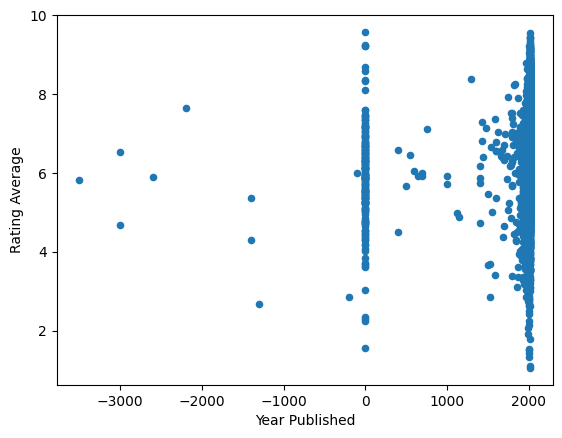

In [131]:
df_join.plot.scatter(x="Year Published", y="Rating Average")